#Bank Customer Churn Prediction using ANN

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

##Load Dataset

In [3]:
df = pd.read_csv("/content/Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Data Exploration

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


##Shape

In [6]:
df.shape

(10000, 14)

##Size

In [7]:
df.size

140000

##Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


##Description

In [9]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## Unique values for each column

In [12]:
for col in df.columns:
    print(f"\nColumn Name : {col}")
    print(df[col].unique())
    print(f"Number of Unique Values : {df[col].nunique()}")


Column Name : RowNumber
[    1     2     3 ...  9998  9999 10000]
Number of Unique Values : 10000

Column Name : CustomerId
[15634602 15647311 15619304 ... 15584532 15682355 15628319]
Number of Unique Values : 10000

Column Name : Surname
['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
Number of Unique Values : 2932

Column Name : CreditScore
[619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 

## Number of unique values for each column

In [13]:
df.nunique()

,0
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


##Dropping Columns

- RowNumber  : Just a serial number (1, 2, 3...) — no relationship to churn

- CustomerId : A random unique ID — has no predictive meaning

- Surname    : Customer's last name — a name has no logical connection to whether someone churns



In [14]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


##  Standardize the column names

In [16]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_").str.replace("-","_")
df.columns

Index(['creditscore', 'geography', 'gender', 'age', 'tenure', 'balance',
       'numofproducts', 'hascrcard', 'isactivemember', 'estimatedsalary',
       'exited'],
      dtype='object')

In [18]:
df = df.rename(columns={
    'numofproducts': 'num_of_products',
    'hascrcard': 'has_cr_card',
    'isactivemember': 'is_active_member',
    'estimatedsalary': 'estimated_salary',
    'creditscore': 'credit_score'
})

In [19]:
df.columns

Index(['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance',
       'num_of_products', 'has_cr_card', 'is_active_member',
       'estimated_salary', 'exited'],
      dtype='object')

## Target Variable Distribution

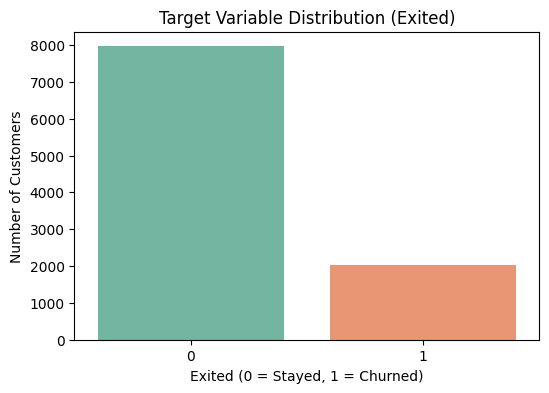

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='exited', data=df, palette='Set2')
plt.title('Target Variable Distribution (Exited)')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

## Key Insights

- Dataset is moderately imbalanced.
- Retained customers are significantly higher than churned customers.
- Most customers continued using the bank's services.
- A smaller portion of customers exited the bank.

## Approximate Observation

- Around 80% → Retained (Exited = 0)
- Around 20% → Churned (Exited = 1)

## Numerical Feature Distribution

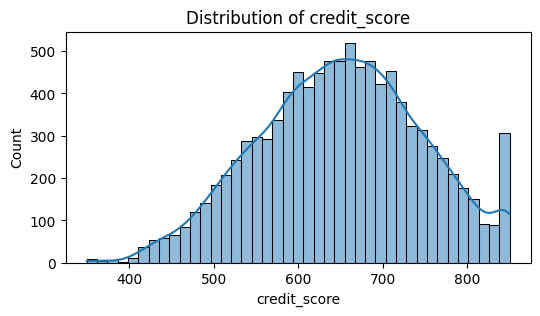

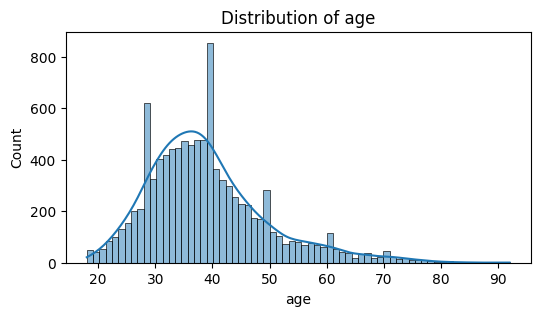

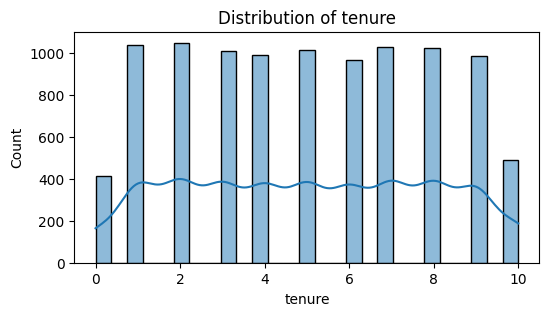

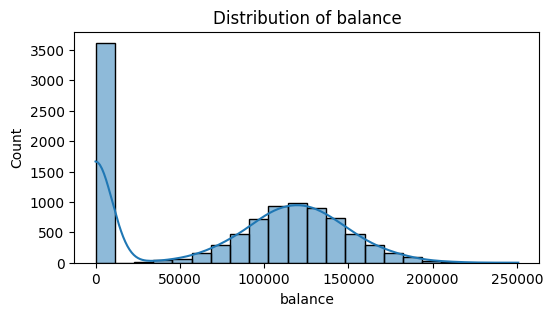

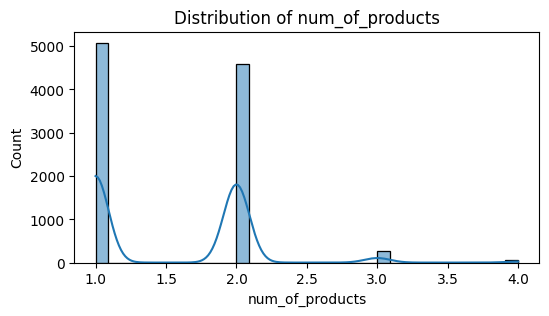

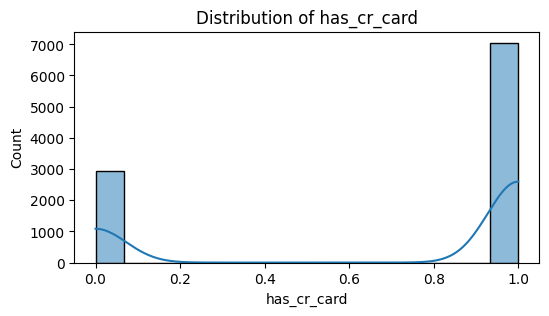

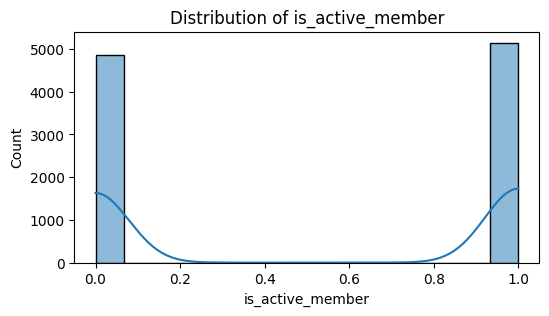

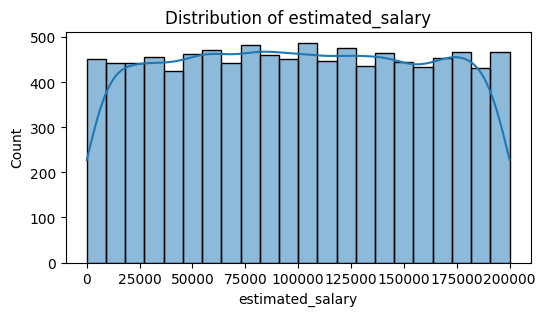

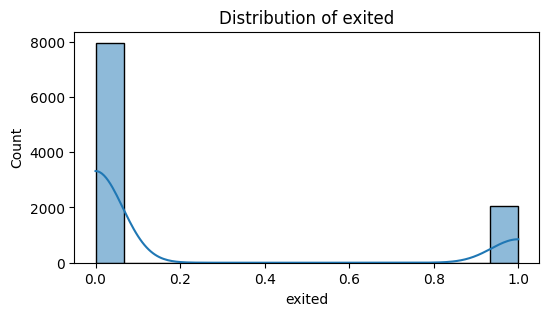

In [21]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

1. Credit_Score
- Most customers have a credit score between 600 and 700.
- Extremely low and very high credit scores are less common.

2. Age
- The majority of customers are between 30 and 45 years old.
- The distribution is slightly right-skewed, with fewer older customers.

3. Tenure
- Customers are fairly evenly distributed across different tenure values.
- No single tenure period dominates the dataset.

4. Balance
- A noticeable number of customers have zero account balance.
- The remaining balances are spread across a wide range of values.

5. Num_Of_Products
- Most customers own 1 or 2 banking products.
- Very few customers have 3 or 4 products.

6. Has_Cr_Card
- Most customers possess a credit card.
- The distribution shows that credit card ownership is common among customers.

7. Is_Active_Member
- Active and inactive members are almost evenly distributed.
- The dataset contains a balanced representation of both customer types.

8. Estimated_Salary
- Customer salaries are uniformly distributed across the salary range.
- There is no strong concentration around any particular salary level.

9. Exited (Target Variable)
- Most customers were retained, while a smaller portion left the bank.
- The dataset is moderately imbalanced, with approximately 80% retained and 20% churned.

## Checking Outliers

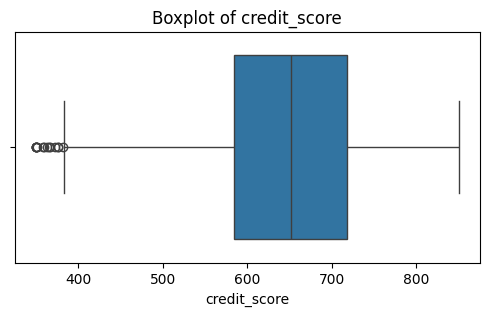

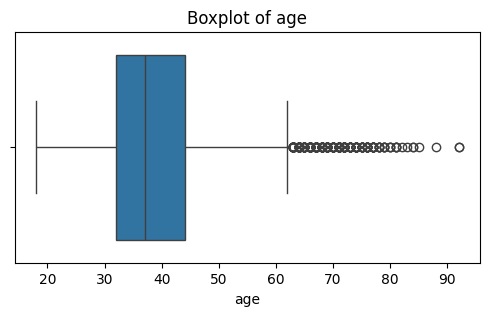

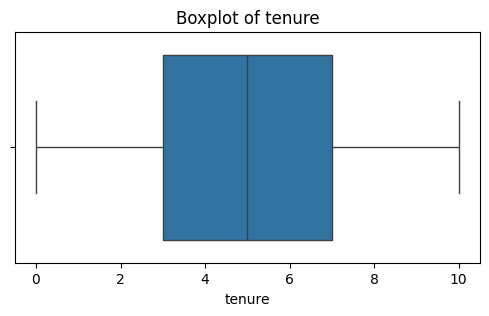

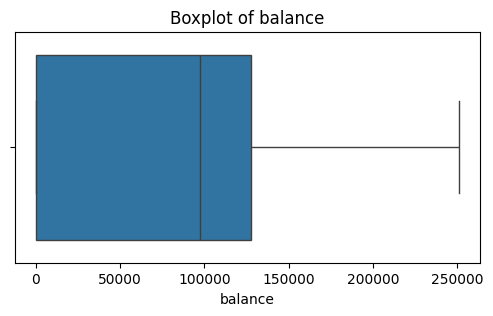

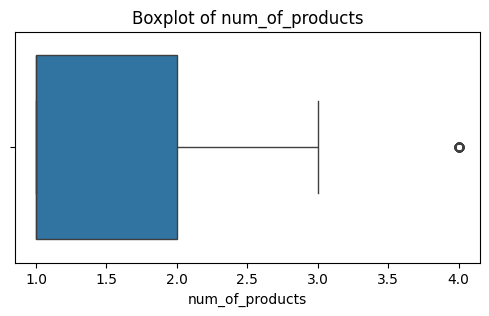

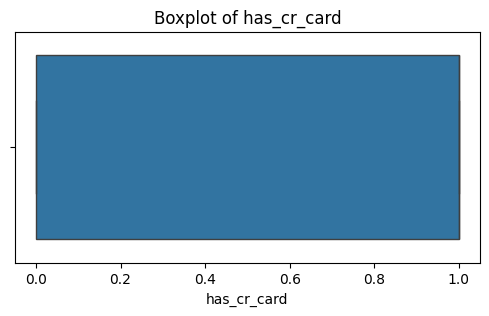

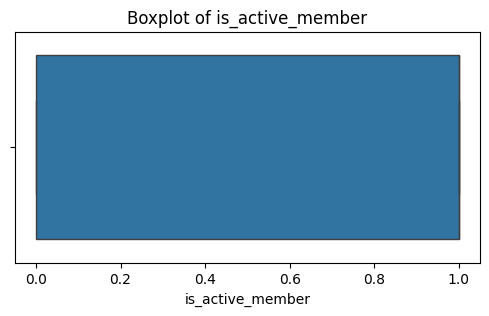

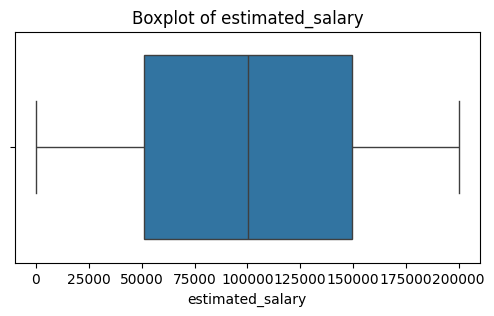

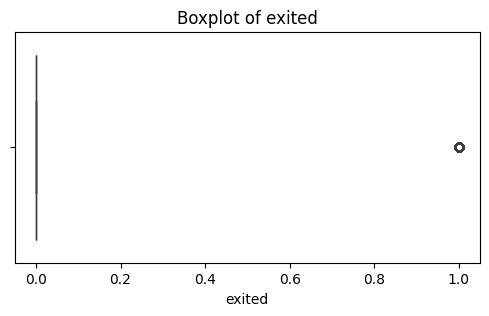

In [22]:
for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

##Geography vs Exited

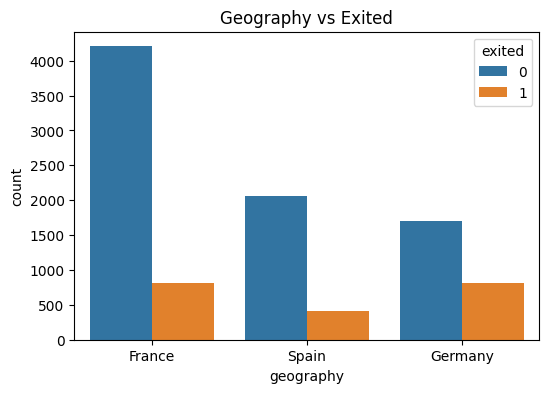

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='geography', hue='exited', data=df)
plt.title('Geography vs Exited')
plt.show()

## Gender vs Exited

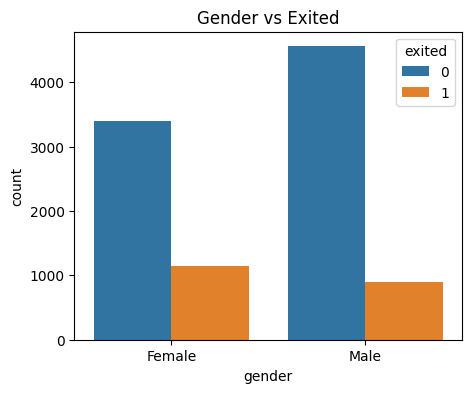

In [23]:
plt.figure(figsize=(5,4))
sns.countplot(x='gender', hue='exited', data=df)
plt.title('Gender vs Exited')
plt.show()

## Is_Active_Member vs Exited

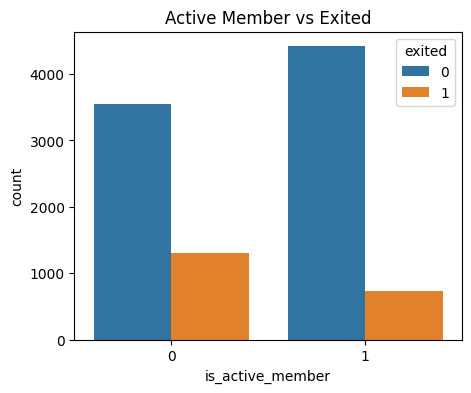

In [24]:
plt.figure(figsize=(5,4))
sns.countplot(x='is_active_member', hue='exited', data=df)
plt.title('Active Member vs Exited')
plt.show()

## Num_Of_Products vs Exited

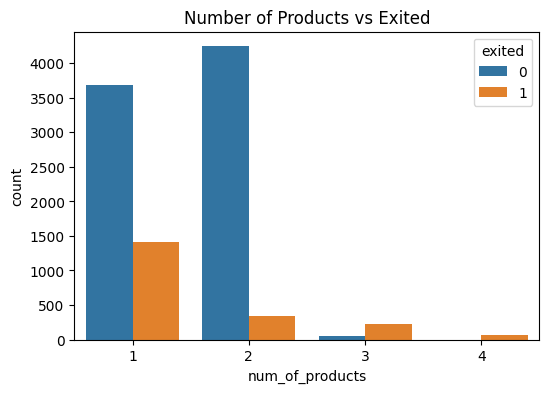

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='num_of_products', hue='exited', data=df)
plt.title('Number of Products vs Exited')
plt.show()

## Has_Cr_Card vs Exited

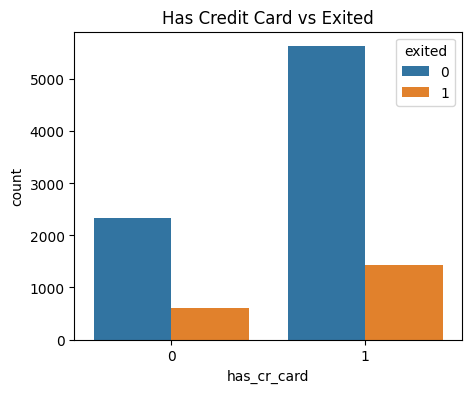

In [26]:
plt.figure(figsize=(5,4))
sns.countplot(x='has_cr_card', hue='exited', data=df)
plt.title('Has Credit Card vs Exited')
plt.show()

## Key Insights from EDA
- The dataset shows a moderate class imbalance, with most customers remaining with the bank.
- Customer age appears to influence churn, with older customers showing a higher likelihood of leaving.
- Active members are more likely to stay, while inactive members have higher churn rates.
- Customers with fewer banking products tend to churn more frequently than those using multiple products.
- Customer geography has an impact on churn, with noticeable differences across regions.
- Gender shows a slight variation in churn behavior, but its impact is less significant than other features.
- Customers with higher account balances tend to exhibit relatively higher churn.
- Credit score, tenure, and estimated salary show varying distributions but appear to have a weaker individual effect on churn compared to age and activity status.

## Correlation Heatmap

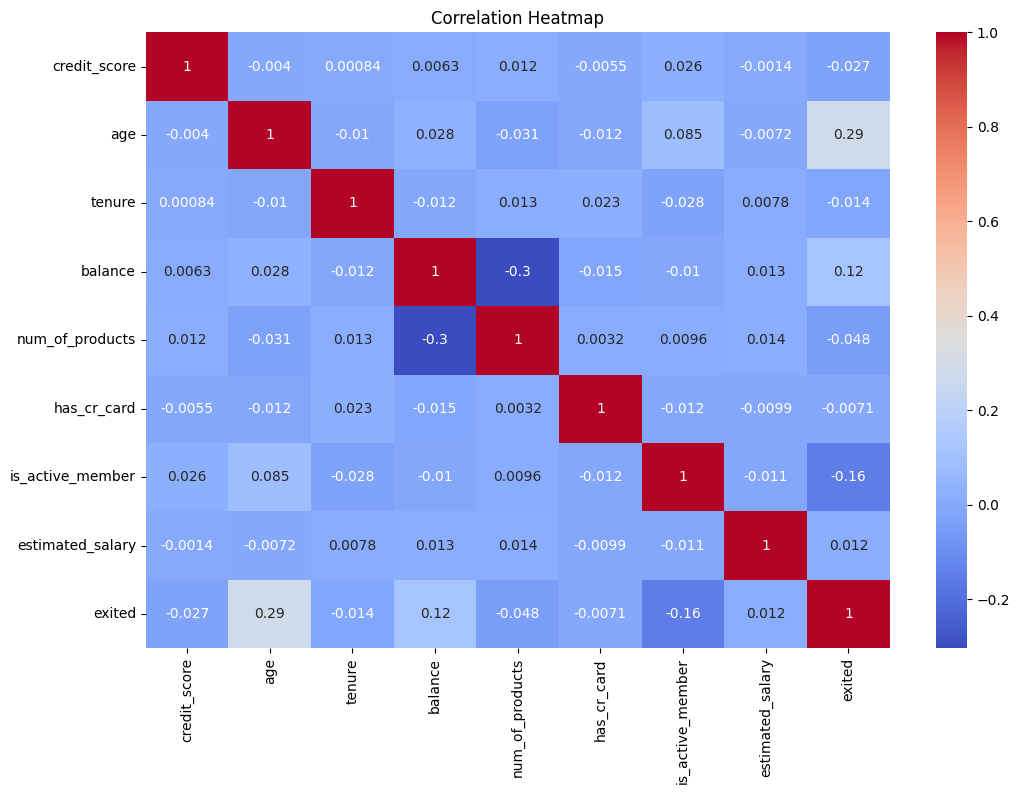

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## Key Insights

- Age shows the strongest positive relationship with churn.
- Active members are less likely to leave the bank.
- Most features have weak correlations, indicating low multicollinearity.
- The numerical features provide useful inputs for training the Artificial Neural Network (ANN).

# Feature scaling

## Separate Features and Target

In [28]:
X = df.drop('exited', axis=1)
y = df['exited']

In [29]:
X = pd.get_dummies(X, columns=['geography', 'gender'], drop_first=True)

## Train / Validation / Test Split

A 3-way split is used for ANN training:

- Train (70%) – Used to train the ANN model.
- Validation (15%) – Used to monitor validation loss and tune hyperparameters.
- Test (15%) – Used only once to evaluate the final model performance.

In [30]:
# First split: 85% train+validation, 15% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Second split: 70% train, 15% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_full
)

print("Training Set   :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set    :", X_test.shape)

Training Set   : (6999, 11)
Validation Set : (1501, 11)
Testing Set    : (1500, 11)


In [31]:
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((6999, 11), (1501, 11), (1500, 11), (6999,), (1501,), (1500,))

In [32]:
# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ANN Model (TensorFlow / Keras)

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

tf.random.set_seed(42)
print("TF version:", tf.__version__)

TF version: 2.20.0


## Handle Class Imbalance

Compute class weights so the network pays proportionally more attention to the
minority (churned) class instead of just predicting "stayed" every time.

In [34]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
class_weight

{np.int64(0): np.float64(0.6278256189451022),
 np.int64(1): np.float64(2.4557894736842107)}

## Build a Regularized ANN

- L2 weight regularization + Dropout + BatchNormalization to prevent overfitting
- Lower learning rate (0.0005) for stabler convergence
- EarlyStopping + ReduceLROnPlateau so training stops at the right point

In [35]:
from tensorflow.keras import layers, regularizers

In [37]:
n_features = X_train.shape[1]

def build_model(n_features):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),

        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

ann_model = build_model(n_features)
ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 96 (384.00 B)

## Train the Model

In [38]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

history = ann_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.3442 - auc: 0.5505 - loss: 0.8122 - precision: 0.2132 - recall: 0.8253 - val_accuracy: 0.3524 - val_auc: 0.6417 - val_loss: 0.7874 - val_precision: 0.2230 - val_recall: 0.8758 - learning_rate: 5.0000e-04
Epoch 2/150
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4715 - auc: 0.6120 - loss: 0.7312 - precision: 0.2405 - recall: 0.7396 - val_accuracy: 0.5769 - val_auc: 0.7279 - val_loss: 0.7204 - val_precision: 0.2962 - val_recall: 0.7810 - learning_rate: 5.0000e-04
Epoch 3/150
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5762 - auc: 0.6592 - loss: 0.7030 - precision: 0.2775 - recall: 0.6744 - val_accuracy: 0.6736 - val_auc: 0.7569 - val_loss: 0.6879 - val_precision: 0.3535 - val_recall: 0.7255 - learning_rate: 5.0000e-04
Epoch 4/150
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6194 - auc: 0.6826 - loss: 0.6856 - precision: 0.2994 - recall: 0.6491 - val_accuracy: 0.7002 - val_auc: 0.7700 - val

## Training Curves

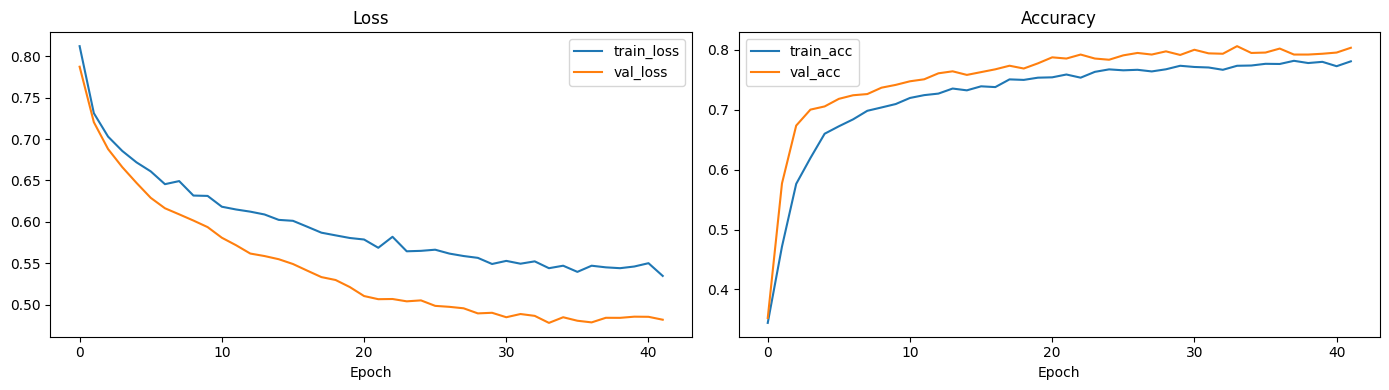

In [41]:
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_df['loss'], label='train_loss')
axes[0].plot(hist_df['val_loss'], label='val_loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(hist_df['accuracy'], label='train_acc')
axes[1].plot(hist_df['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.show()

Train/val curves should stay close together, and val_loss should flatten rather than climb. A widening gap means overfitting — reduce capacity or raise L2 further.

## Threshold Tuning (on Validation Set)

Find the probability cutoff that maximizes F1 on the churn class, instead of
blindly using 0.5.

In [42]:
from sklearn.metrics import f1_score

In [43]:
y_pred_proba_val = ann_model.predict(X_val).ravel()

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val, (y_pred_proba_val >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold (chosen on validation set): {best_threshold:.2f}, Val F1: {max(f1_scores):.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Best threshold (chosen on validation set): 0.65, Val F1: 0.6528


## Final, One-Time Evaluation on the Held-Out Test Set

In [45]:
y_pred_proba_test = ann_model.predict(X_test).ravel()
y_pred_test = (y_pred_proba_test >= best_threshold).astype(int)

test_acc = accuracy_score(y_test, y_pred_test)
test_auc = roc_auc_score(y_test, y_pred_proba_test)

print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test ROC-AUC   : {test_auc:.4f}")
print(f"Threshold used : {best_threshold:.2f}")
print()
print(confusion_matrix(y_test, y_pred_test))
print()
print(classification_report(y_test, y_pred_test))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Accuracy  : 0.8427
Test ROC-AUC   : 0.8559
Threshold used : 0.65

[[1082  112]
 [ 124  182]]

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1194
           1       0.62      0.59      0.61       306

    accuracy                           0.84      1500
   macro avg       0.76      0.75      0.75      1500
weighted avg       0.84      0.84      0.84      1500



## Save Model and Scaler

Both are needed for deployment, so new raw customer data gets scaled identically to training.

In [47]:
import joblib
import json as _json
import os

os.makedirs('artifacts', exist_ok=True)

joblib.dump(scaler, 'artifacts/scaler.joblib')
ann_model.save('artifacts/churn_model.keras')

metadata = {
    'threshold': float(best_threshold),
    'feature_columns': list(X.columns),
    'test_accuracy': float(test_acc),
    'test_auc': float(test_auc)
}
with open('artifacts/metadata.json', 'w') as f:
    _json.dump(metadata, f, indent=2)

print("Saved: artifacts/scaler.joblib, churn_model.keras, metadata.json")

Saved: artifacts/scaler.joblib, churn_model.keras, metadata.json


In [48]:
import os
print(os.listdir("artifacts"))

['scaler.joblib', 'metadata.json', 'churn_model.keras']


In [49]:
import json

with open("artifacts/metadata.json") as f:
    metadata = json.load(f)

print(metadata)


{'threshold': 0.6499999999999997, 'feature_columns': ['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'geography_Germany', 'geography_Spain', 'gender_Male'], 'test_accuracy': 0.8426666666666667, 'test_auc': 0.855943661663437}


In [51]:
import json

with open("artifacts/metadata.json") as f:
    metadata = json.load(f)

print(metadata)

{'threshold': 0.6499999999999997, 'feature_columns': ['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'geography_Germany', 'geography_Spain', 'gender_Male'], 'test_accuracy': 0.8426666666666667, 'test_auc': 0.855943661663437}


In [52]:
import shutil
shutil.make_archive('artifacts', 'zip', 'artifacts')

from google.colab import files
files.download('artifacts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>